# 1

Create a series of 10 elements, random integers from 70 to 100, representing scores on a monthly exam. Set the index to be the month names, starting in September and ending in June.

With this series, write code to answer the following questions:
- What is the student’s average test score for the entire year?
- What is the student’s average test score during the first half of the year (i.e., the first five months)?
- What is the student’s average test score during the second half of the year?
- Did the students improve their performance in the second half? If so, by how much?

In [259]:
import pandas as pd
import numpy as np
import random

In [260]:
g = np.random.default_rng()

In [261]:
m = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
s = pd.Series(g.integers(70, 101, 10), index = m)

In [262]:
s

Sep     87
Oct     71
Nov     94
Dec     95
Jan     98
Feb     98
Mar     71
Apr     86
May    100
Jun     85
dtype: int64

In [263]:
year_mean = s.mean()
first_half = s.loc['Sep':'Jan'].mean()
second_half = s['Feb':'Jun'].mean()
difference = second_half - first_half
print(f"Year mean: {year_mean}")
print(f"First half: {first_half}")
print(f"Second half: {second_half}")
print(f"Difference: {difference}")

Year mean: 88.5
First half: 89.0
Second half: 88.0
Difference: -1.0


- In which month did the student perform best?
- What were the student’s five highest scores?
- Round the student’s scores to the nearest 10.

In [264]:
s.idxmax()

'May'

In [265]:
s.nlargest(5)

May    100
Jan     98
Feb     98
Dec     95
Nov     94
dtype: int64

In [266]:
s.round(-1)

Sep     90
Oct     70
Nov     90
Dec    100
Jan    100
Feb    100
Mar     70
Apr     90
May    100
Jun     80
dtype: int64

# 2

Generate 10 test scores between 40 and 60, again using an index starting with September and ending with June. Find the mean of the scores and add the difference between the mean and 80 to each of the scores.

In [267]:
m = ['Sep', 'Oct', 'Nov', 'Dece', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
s = pd.Series(g.integers(40, 61, 10), index = m)

In [268]:
s

Sep     50
Oct     58
Nov     60
Dece    47
Jan     40
Feb     43
Mar     48
Apr     56
May     41
Jun     50
dtype: int64

In [269]:
s.mean()

np.float64(49.3)

In [270]:
s + (80 - s.mean())

Sep     80.7
Oct     88.7
Nov     90.7
Dece    77.7
Jan     70.7
Feb     73.7
Mar     78.7
Apr     86.7
May     71.7
Jun     80.7
dtype: float64

# 3

Generate 10 random integers in the range 0 to 100

In [271]:
s1 = pd.Series(g.integers(0, 101, 10))
s1

0    74
1    42
2    69
3    27
4    12
5    41
6    40
7    36
8    13
9    17
dtype: int64

Create a series containing those numbers’ tens digits.

In [272]:
s2 = s1 // 10
s2

0    7
1    4
2    6
3    2
4    1
5    4
6    4
7    3
8    1
9    1
dtype: int64

Create a new series with 10 floating-point values between 0 and 1,000.

In [273]:
s = pd.Series(g.random(10) * 1000)
s

0    867.566590
1    980.925483
2    920.591748
3    200.315898
4    266.638362
5     42.845553
6     38.195872
7     89.470958
8    805.373145
9    740.031144
dtype: float64

Find the numbers whose integer component (i.e., ignoring any fractional part) are even.

In [274]:
s[s.astype(int) % 2 == 0]

1    980.925483
2    920.591748
3    200.315898
4    266.638362
5     42.845553
6     38.195872
9    740.031144
dtype: float64

# 4

Generate a series of 100,000 floats in a normal distribution with a mean of 0 and a standard deviation of 100.

In [275]:
s = pd.Series(g.normal(0, 100, 100000))
s

0         -5.166133
1       -139.974623
2        -24.195106
3       -262.103118
4         68.233337
            ...    
99995   -115.798931
99996     -4.749530
99997    107.933683
99998   -100.571762
99999     63.471776
Length: 100000, dtype: float64

Get the descriptive statistics for this series

In [276]:
s.describe()

count    100000.000000
mean         -0.007148
std          99.959745
min        -422.536978
25%         -67.254189
50%           0.168232
75%          67.129173
max         425.319980
dtype: float64

Replace the minimum value with five times the maximum value.

In [277]:
s.min(), s.max()

(np.float64(-422.53697788284626), np.float64(425.3199799591295))

In [278]:
s.loc[s.idxmin()] = 5 * s.max()

Get the descriptive statistics again.

In [279]:
s.describe()

count    100000.000000
mean          0.018343
std         100.176792
min        -394.844105
25%         -67.252288
50%           0.170697
75%          67.129945
max        2126.599900
dtype: float64

Demonstrate that 68%, 95%, and 99.7% of the values in s are indeed within one, two, and three standard distributions of the mean.

In [280]:
# Calculate mean and std once to avoid repeated calculations
mean = s.mean()
std = s.std()

# Define function to calculate percentage within n standard deviations
def percentage_within_std(series, n_std, mean=mean, std=std):
    """Calculate percentage of values within n standard deviations from the mean"""
    within_range = series[(series >= mean - n_std * std) & (series <= mean + n_std * std)]
    return (within_range.count() / series.count()) * 100

# Calculate and display percentages for 1, 2, and 3 standard deviations
std_ranges = [1, 2, 3]
expected = [68, 95, 99.7]  # Expected percentages according to the empirical rule

for i, n_std in enumerate(std_ranges):
    actual_pct = percentage_within_std(s, n_std)
    print(f"Within {n_std} std dev: {actual_pct:.2f}% (Expected: {expected[i]}%)")

Within 1 std dev: 68.39% (Expected: 68%)
Within 2 std dev: 95.48% (Expected: 95%)
Within 3 std dev: 99.75% (Expected: 99.7%)


Calculate the mean of numbers greater than s.mean(). Then calculate the mean of numbers less than s.mean(). Is the average of these two numbers the same as s.mean()?

In [281]:
mean = s.mean()
# Calculate the mean of numbers greater than s.mean()
greater_than_mean = s[s > s.mean()].mean()
# Calculate the mean of numbers less than s.mean()
less_than_mean = s[s < s.mean()].mean()
# Calculate the mean of all numbers
combined = s.mean()
# Check if the average of the two means is equal to s.mean()
is_equal = (greater_than_mean + less_than_mean) / 2 == combined
print(f"Mean of numbers greater than s.mean(): {greater_than_mean}")
print(f"Mean of numbers less than s.mean(): {less_than_mean}")
print(f"Combined mean: {combined}")
print(f"Is the average of the two means equal to s.mean() {mean}? {is_equal}")

Mean of numbers greater than s.mean(): 79.6988189389725
Mean of numbers less than s.mean(): -79.7897228174482
Combined mean: 0.018343477464726324
Is the average of the two means equal to s.mean() 0.018343477464726324? False


What is the mean of the numbers beyond three standard deviations?

In [282]:
beyond_3_std = s[(s < mean - 3 * std) | (s > mean + 3 * std)]
# Calculate the mean of numbers beyond 3 standard deviations
beyond_3_std_mean = beyond_3_std.mean()
print(f"Mean of numbers beyond 3 std: {beyond_3_std_mean}")

Mean of numbers beyond 3 std: -11.316107439152573


## 5

Create a series of 28 temperature readings, representing four seven-day weeks, randomly generated from a normal distribution with a mean of 20 and a standard deviation of 5, rounded to the nearest integer. Use the days of the week as the index.

In [283]:
g = np.random.default_rng()
g.normal(20, 5, 28)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
s = pd.Series(g.normal(20, 5, 28), index = days * 4).round().astype(int)

In [284]:
s

Mon    21
Tue    33
Wed    13
Thu    15
Fri    13
Sat    31
Sun    19
Mon    21
Tue    22
Wed    22
Thu    20
Fri    15
Sat    11
Sun    14
Mon    22
Tue    22
Wed    21
Thu    24
Fri    18
Sat    18
Sun    16
Mon    20
Tue    12
Wed    17
Thu    21
Fri    24
Sat    18
Sun    26
dtype: int64

Mean temperature on Mondays:

In [285]:
s.loc['Mon'].mean()

np.float64(21.0)

Mean temperature for each day of the week:

In [286]:
s.groupby(s.index).mean()

Fri    17.50
Mon    21.00
Sat    19.50
Sun    18.75
Thu    20.00
Tue    22.25
Wed    18.25
dtype: float64

Weekend mean temperatures:

In [287]:
weekend_mean = s.loc[['Sat', 'Sun']].mean()
weekend_mean

np.float64(19.125)

How many times is the change in temperature from the previous day greater than 2 degrees?

In [288]:
# How many times is the change in temperature from the previous day greater than 2 degrees?
difference = s.diff().abs() > 2
difference.value_counts()

True     17
False    11
Name: count, dtype: int64

What are the two most common temperatures in our data set, and how often does each appear?

In [289]:
s.value_counts().nlargest(2)

21    4
22    4
Name: count, dtype: int64

## 6

In [290]:
s = pd.read_csv('data/taxi-passenger-count.csv', header=None).squeeze()

In [291]:
s.info()

<class 'pandas.core.series.Series'>
RangeIndex: 9999 entries, 0 to 9998
Series name: 0
Non-Null Count  Dtype
--------------  -----
9999 non-null   int64
dtypes: int64(1)
memory usage: 78.2 KB


What percentage of taxi rides had only one passenger versus the (theoretical) maximum of six passengers.

In [292]:
s.value_counts()[[1, 6]]

0
1    7207
6     369
Name: count, dtype: int64

In [293]:
sample_percentage = s.value_counts(normalize=True)[[1, 6]] * 100
sample_percentage.round(2)

0
1    72.08
6     3.69
Name: proportion, dtype: float64

Given these numbers, would more people benefit from smaller taxis that can take only one or two passengers or larger taxis that can take five or six passengers?

In [294]:
total_percentage = s.value_counts(normalize=True) * 100
total_percentage.round(2)

0
1    72.08
2    13.13
5     5.20
3     4.06
6     3.69
4     1.82
0     0.02
Name: proportion, dtype: float64

In [295]:
smaller_taxi = s.value_counts(normalize=True)[[1,2]].sum() * 100
larger_taxi = s.value_counts(normalize=True)[[5,6]].sum() * 100
if smaller_taxi > larger_taxi:
    print("More people would benefit from smaller taxis.")
else:
    print("More people would benefit from larger taxis.")
print(f"Percentage of smaller taxi: {smaller_taxi:.2f}%")
print(f"Percentage of larger taxi: {larger_taxi:.2f}%")

More people would benefit from smaller taxis.
Percentage of smaller taxi: 85.21%
Percentage of larger taxi: 8.89%


## 7

In [296]:
s = pd.read_csv('data/taxi-distance.csv', header=None).squeeze()

In [297]:
s.info()

<class 'pandas.core.series.Series'>
RangeIndex: 9999 entries, 0 to 9998
Series name: 0
Non-Null Count  Dtype  
--------------  -----  
9999 non-null   float64
dtypes: float64(1)
memory usage: 78.2 KB


In [298]:
s.head()

0    1.63
1    0.46
2    0.87
3    2.13
4    1.40
Name: 0, dtype: float64

In [299]:
s.describe()

count    9999.000000
mean        3.158511
std         4.037516
min         0.000000
25%         1.000000
50%         1.700000
75%         3.300000
max        64.600000
Name: 0, dtype: float64

Modify the series (or create another series) containing category names rather than numbers based on these criteria:
- Short, <= 2 miles
- Medium, > 2 miles but <= 10 miles
- Long, > 10 miles

In [300]:
pd.cut(s,
        bins=[0, 2, 10, s.max()],
        include_lowest=True,
        labels=['short', 'medium', 'long']).value_counts()

0
short     5890
medium    3402
long       707
Name: count, dtype: int64

Visualize the distribution of the distances using a histogram.

<Axes: ylabel='Frequency'>

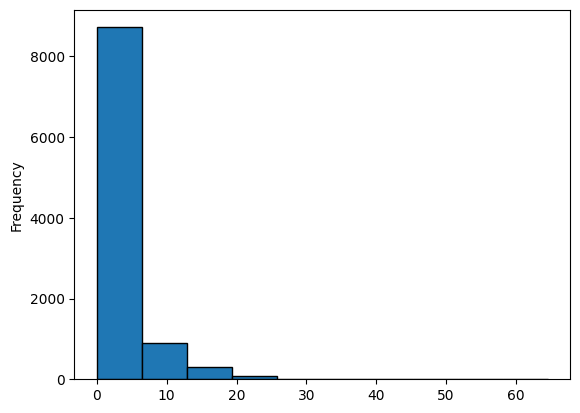

In [325]:
s.plot.hist(edgecolor='black')

How many short, medium, and long trips were there for trips that had only one passenger? Note that the data for passenger count and trip length is from the same data set, meaning the indexes are the same.

In [326]:
passengers = pd.read_csv('data/taxi-passenger-count.csv', header=None).squeeze()
distance = pd.read_csv('data/taxi-distance.csv', header=None).squeeze()

In [329]:
df = pd.concat([passengers, distance], axis=1)
df.columns = ['passengers', 'distance']
# replace the distance with the categories
df['distance'] = pd.cut(df['distance'],
                         bins=3,
                         include_lowest=True,
                         labels=['short', 'medium', 'long'])

In [330]:
one_passenger = df[df['passengers'] == 1]
one_passenger['distance'].value_counts()

distance
short     7179
medium      26
long         2
Name: count, dtype: int64